Loaded dataset using modeling model-ready
Featurization package info: {'package_name': 'kmds-featurization', 'version': '0.3.2', 'entry_point': 'featurization-cli', 'cli_commands': ['init', 'bootstrap', 'run', 'advise', 'check', 'add-stage'], 'documentation_note': 'This package no longer ships internal docs in the installed package. Use the repository top-level documents/ folder for onboarding and implementation guidance.', 'usage': {'overview': 'Use this package by configuring a workspace in featurizer_config.yaml, then running the CLI from that workspace. For cross-sectional workflows, follow the cross-sectional guide; for event-log survival workflows, follow the survival guide.', 'cross_sectional_guide': 'documents/user_guide_cs_featurization.md', 'survival_guide': 'documents/survival_featurization_pipeline.md', 'guidance': 'Feature selection is recommended for wide and short datasets. This package does not provide a dedicated featurization pipeline for wide and short datasets.'}}
F

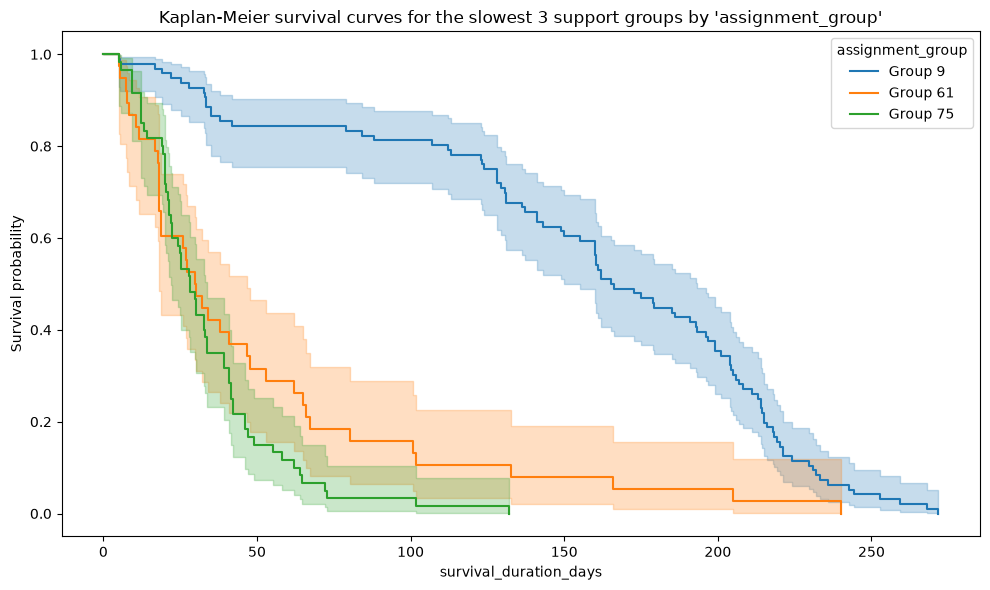

In [1]:
from pathlib import Path
import yaml
import pandas as pd
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

import featurization
from featurization import notebook_utils as featurization_nb
from featurization.notebook_utils import (
    build_notebook_resolver,
    load_featurized_dataset,
    load_model_ready_dataset as load_featurization_model_ready_dataset,
)
from kmds_modeling import get_package_info, get_spec_questions, build_model_spec
from kmds_modeling.core import notebook_utils as modeling_nb
from kmds_modeling.core.path_coordinator import PathCoordinator as ModelingPathCoordinator

root = Path('.').resolve()
if root.name == 'notebooks' and (root.parent / 'featurizer_config.yaml').exists():
    root = root.parent
else:
    workspace_root = root
    while workspace_root != workspace_root.parent:
        if (workspace_root / 'featurizer_config.yaml').exists() or (workspace_root / 'config.yaml').exists():
            root = workspace_root
            break
        workspace_root = workspace_root.parent
notebook_dir = root / 'notebooks'
if not notebook_dir.exists() or not notebook_dir.is_dir():
    notebook_dir = root


def load_yaml(path):
    with open(path, 'r', encoding='utf-8') as f:
        return yaml.safe_load(f) or {}


def find_file(patterns):
    for pattern in patterns:
        matches = list(root.glob(pattern))
        if matches:
            return matches[0]
    return None

featurization_info = featurization.get_package_info()
modeling_info = get_package_info()
featurizer_config = featurization_nb.load_workspace_config_from_notebook_dir(str(notebook_dir))

featurization_resolver = build_notebook_resolver(str(notebook_dir))

modeling_config = {}
modeling_config_path = root / 'modeling_config.yaml'
if modeling_config_path.exists():
    modeling_config = modeling_nb.load_workspace_config(str(root), config_name='modeling_config.yaml')
modeling_config.setdefault('featurization_output_dir', featurizer_config.get('featurization_output_dir', 'featurization'))
modeling_config.setdefault('model_ready_data_file', featurizer_config.get('itsm_KM_data_file', 'itsm_KM_data.csv'))
modeling_resolver = ModelingPathCoordinator(str(root), modeling_config)
modeling_artifacts = modeling_nb.get_modeling_artifact_paths(modeling_resolver)

dataset_loaders = [
    ("modeling model-ready", modeling_nb.load_model_ready_dataset, modeling_resolver),
    ("featurization featurized", load_featurized_dataset, featurization_resolver),
    ("featurization model-ready", load_featurization_model_ready_dataset, featurization_resolver),
]

df = None
for name, loader, resolver in dataset_loaders:
    try:
        df = loader(resolver)
        print(f"Loaded dataset using {name}")
        break
    except FileNotFoundError as exc:
        print(f"Could not load dataset using {name}: {exc}")

if df is None:
    raise RuntimeError("Could not load the dataset through featurization/modeling notebook interfaces.")
if not isinstance(df, pd.DataFrame):
    raise RuntimeError("Loaded dataset is not a pandas DataFrame.")

config_path = find_file(['config.yaml', '**/config.yaml'])
config = load_yaml(config_path) if config_path else {}
dataset_questions_path = find_file(['**/*dataset*question*.y*ml', '**/*questions*.y*ml', '**/*dataset*meta*.y*ml'])
dataset_questions = load_yaml(dataset_questions_path) if dataset_questions_path else {}

requirements = {
    "project": {
        "task_type": "SURVIVAL_ANALYSIS",
        "dataset_type": config.get("dataset_type", "event_log"),
        "dataset_id": config.get("dataset_id"),
        "project_name": "ITSM Kaplan-Meier Survival Analysis",
    }
}

spec_questions = get_spec_questions(requirements)
model_spec = build_model_spec(requirements)

print("Featurization package info:", featurization_info)
print("Featurization resolver model-ready path:", featurization_resolver.model_ready_dataset_path)
print("Featurization resolver featurized path:", featurization_resolver.featurized_dataset_path)
print("Modeling package info:", modeling_info)
print("Loaded modeling artifacts:", modeling_artifacts)
print("Loaded dataset shape:", df.shape)
print("Model spec questions count:", len(spec_questions))
print("Model spec type:", type(model_spec))


def recursive_find_key(data, keywords):
    if isinstance(data, dict):
        for key, value in data.items():
            if any(word in key.lower() for word in keywords):
                return key, value
            found = recursive_find_key(value, keywords)
            if found is not None:
                return found
    return None


def find_best_column(columns, keywords, exclude=None):
    exclude = set(exclude or [])
    for col in columns:
        if col in exclude:
            continue
        lower = col.lower()
        if any(word in lower for word in keywords):
            return col
    return None


event_key = None
duration_key = None

event_search = recursive_find_key(dataset_questions, ['event', 'status', 'outcome'])
duration_search = recursive_find_key(dataset_questions, ['duration', 'time', 'followup'])
if event_search:
    event_key = event_search[0]
if duration_search:
    duration_key = duration_search[0]

if event_key is None:
    event_key = find_best_column(df.columns, ['event', 'status', 'outcome'])

if duration_key is None:
    duration_key = find_best_column(df.columns, ['duration', 'time', 'followup'], exclude=[event_key] if event_key else None)
    if duration_key is None:
        duration_key = find_best_column(df.columns, ['survival'], exclude=[event_key] if event_key else None)

if event_key is None or duration_key is None:
    raise ValueError("Could not infer event or duration columns from the dataset and questions.")

candidate_group_cols = [c for c in df.columns if c not in {event_key, duration_key}]
# Prefer an assignment or group column for stratified curves; use the first available categorical column otherwise.
group_col = find_best_column(candidate_group_cols, ['group', 'assignment', 'cohort', 'segment', 'category'])
if group_col is None and candidate_group_cols:
    group_col = candidate_group_cols[0]

print("Loaded dataset shape:", df.shape)
print("Event column:", event_key)
print("Duration column:", duration_key)
print("Group column:", group_col)

kmf = KaplanMeierFitter()
fig, ax = plt.subplots(figsize=(10, 6))

if group_col is not None:
    slowest_groups = (
        df.loc[df[event_key] == 1]
        .groupby(group_col)[duration_key]
        .median()
        .sort_values(ascending=False)
        .head(3)
        .index.tolist()
    )
    if not slowest_groups:
        slowest_groups = (
            df.groupby(group_col)[duration_key]
            .median()
            .sort_values(ascending=False)
            .head(3)
            .index.tolist()
        )
    for grp in slowest_groups:
        mask = df[group_col] == grp
        kmf.fit(df.loc[mask, duration_key], event_observed=df.loc[mask, event_key], label=str(grp))
        kmf.plot_survival_function(ax=ax)
    ax.set_title(f"Kaplan-Meier survival curves for the slowest {len(slowest_groups)} support groups by '{group_col}'")
    ax.legend(title=group_col)
else:
    kmf.fit(df[duration_key], event_observed=df[event_key], label="all")
    kmf.plot_survival_function(ax=ax)
    ax.set_title("Kaplan-Meier survival curve")

ax.set_xlabel(duration_key)
ax.set_ylabel("Survival probability")
plt.tight_layout()

output_dir = Path(modeling_resolver.modeling_output_path)
output_dir.mkdir(parents=True, exist_ok=True)

km_summary = df.groupby(group_col).agg(
    events=(event_key, 'sum'),
    min_duration=(duration_key, 'min'),
    max_duration=(duration_key, 'max'),
    count=(group_col, 'size'),
).sort_values('events', ascending=False).reset_index() if group_col is not None else pd.DataFrame([
    {
        'events': df[event_key].sum(),
        'min_duration': df[duration_key].min(),
        'max_duration': df[duration_key].max(),
        'count': len(df),
    }
])

km_summary_path = output_dir / 'itsm_ticket_survival_km_summary.csv'
fig_path = output_dir / 'itsm_ticket_survival_km.png'
km_summary.to_csv(km_summary_path, index=False)
fig.savefig(fig_path, bbox_inches='tight')
print('Saved KM summary to', km_summary_path)
print('Saved KM plot to', fig_path)
plt.show()
